# Multi-Head Attention
假设我们在翻译这句话：“The animal didn't cross the street because it was too tired.”

从语法角度：“it” 代指的是 “animal”

从语法角度：“it” 代指的是 “animal”

如果只用一个注意力头，模型就很难在一次计算中同时抓住这两个完全不同的维度,它可能会中和掉这两种信息，导致什么都学不好

当给定相同的查询（Query）、键（Key）和值（Value）时，我们希望模型能够基于相同的注意力机制学习到不同的行为

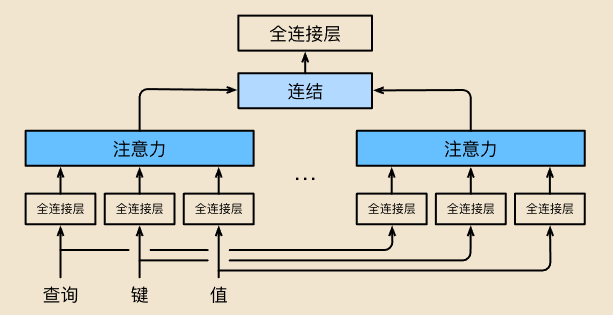

## 模型结构与数学定义
多头注意力的核心步骤可以分为三步：线性投影、并行计算注意力、拼接与输出映射

假设我们有 $h$ 个注意力头。对于每一个头 $i$（$i = 1, \dots, h$），我们都有独立的可学习权重矩阵：

查询权重矩阵：$W_i^{(q)} \in \mathbb{R}^{p_q \times d_q}$

键权重矩阵：$W_i^{(k)} \in \mathbb{R}^{p_k \times d_k}$

值权重矩阵：$W_i^{(v)} \in \mathbb{R}^{p_v \times d_v}$

## Step 1
**线性投影**

对于给定的查询 $q$、键 $k$ 和值 $v$，我们将其分别与对应头的权重矩阵相乘，得到投影后的结果：

$$q_i = W_i^{(q)} q$$

$$k_i = W_i^{(k)} k$$

$$v_i = W_i^{(v)} v$$

## Step 2
**计算各个头的注意力**

将投影后的 $q_i, k_i, v_i$ 喂入普通的注意力函数 $f$（通常是缩放点积注意力）中：
$$head_i = f(q_i, k_i, v_i)$$

## Step 3
**拼接与最终的输出映射**

将所有 $h$ 个头的输出拼接在一起，然后再通过一个最终的可学习输出权重矩阵 $W_o$ 进行一次线性变换，得到多头注意力的最终输出：
$$MultiHead(q, k, v) = W_o \begin{bmatrix} head_1 \\ \vdots \\ head_h \end{bmatrix}$$


In [ ]:
import math
import torch
from torch import nn

def transpose_qkv(X, num_heads):
    """为了多头注意力的并行计算而变换形状"""
    # 输入 X 的形状: (batch_size, 查询或者“键-值”对的个数, num_hiddens)
    # 输出 X 的形状: (batch_size * num_heads, 查询或者“键-值”对的个数, num_hiddens / num_heads)
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)
    X = X.permute(0, 2, 1, 3)
    return X.reshape(-1, X.shape[2], X.shape[3])

def transpose_output(X, num_heads):
    """逆转 transpose_qkv 函数的操作"""
    # 输入 X 的形状: (batch_size * num_heads, 查询的个数, num_hiddens / num_heads)
    # 输出 X 的形状: (batch_size, 查询的个数, num_hiddens)
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)

In [ ]:
class DotProductAttention(nn.Module):
    """缩放点积注意力"""
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        # 这里的 d 是每个头的维度
        d = queries.shape[-1]
        # 计算打分矩阵
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        
        # 将分数转为概率分布
        self.attention_weights = nn.functional.softmax(scores, dim=-1)
        
        return torch.bmm(self.dropout(self.attention_weights), values)

In [ ]:
class MultiHeadAttention(nn.Module):
    """多头注意力机制"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 num_heads, dropout, bias=False, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        
        # 实例化基础的注意力计算模块
        self.attention = DotProductAttention(dropout)
        
        # 声明四个线性投影层
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        # 步骤 1: 线性投影 + 形状变换
        # 将头数维度强行塞进 batch_size 维度，实现并行
        q = transpose_qkv(self.W_q(queries), self.num_heads)
        k = transpose_qkv(self.W_k(keys), self.num_heads)
        v = transpose_qkv(self.W_v(values), self.num_heads)

        if valid_lens is not None:
            # 对应的 valid_lens 也需要复制 num_heads 次
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)

        # 步骤 2: 并行计算基础注意力
        output = self.attention(q, k, v, valid_lens)

        # 步骤 3: 恢复形状 + 拼接
        output_concat = transpose_output(output, self.num_heads)
        
        # 步骤 4: 最终的线性输出映射
        return self.W_o(output_concat)